Dataset: CIFAR‑10, only 200 images, auto‑downloaded, 80–20 split.

EncoderCNN: Extracts image features with a small CNN.

CaptionGenerator: Predicts class name as a simple caption.

VQAModel: Answers a yes/no question → “Is this a dog?”

Training: 5 epochs, using CrossEntropyLoss.

Evaluation: Runs on test set.

Visualization:

Top row → shows image with true & predicted caption.

Bottom row → shows image with question & yes/no answer.

100.0%


Epoch 1, Loss: 3.0299
Epoch 2, Loss: 2.6816
Epoch 3, Loss: 2.5177
Epoch 4, Loss: 2.3663
Epoch 5, Loss: 2.2039
Training complete!


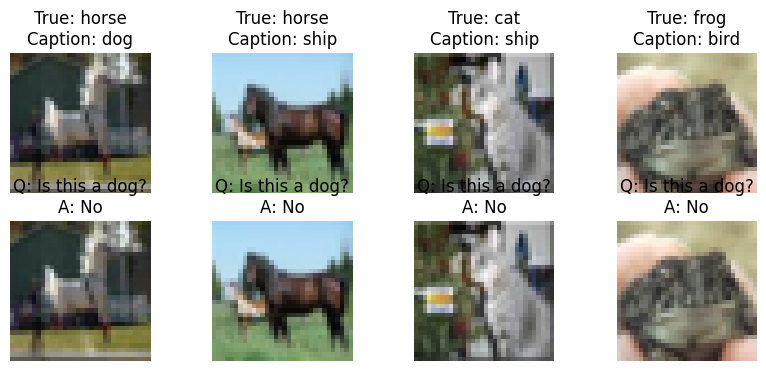

In [ ]:
"""
Experiment 4: Image Captioning and Visual Question Answering (VQA)
------------------------------------------------------------------
This program demonstrates:
1. Image Captioning: generating simple captions for images.
2. Visual Question Answering (VQA): answering yes/no questions about images.
Dataset: CIFAR-10 (200 images, auto-downloaded, 80-20 split).
"""

# Step 1: Import required libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import random

# Step 2: Load CIFAR-10 dataset (200 samples only)
transform = transforms.Compose([transforms.Resize((32,32)), transforms.ToTensor()])
full_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

subset_indices = list(range(200))   # pick first 200 images
small_dataset = Subset(full_dataset, subset_indices)

# Split 80% train, 20% test
train_size = int(0.8 * len(small_dataset))
test_size = len(small_dataset) - train_size
train_set, test_set = random_split(small_dataset, [train_size, test_size])

trainloader = DataLoader(train_set, batch_size=8, shuffle=True)
testloader = DataLoader(test_set, batch_size=8, shuffle=False)

# CIFAR-10 label names
classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

# Step 3: Define a simple CNN encoder for image features
class EncoderCNN(nn.Module):
    def __init__(self):
        super(EncoderCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1), nn.ReLU(), nn.MaxPool2d(2,2),
            nn.Conv2d(16,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2,2)
        )
        self.fc = nn.Linear(32*8*8,128)  # feature vector

    def forward(self,x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# Step 4: Caption Generator (Decoder)
class CaptionGenerator(nn.Module):
    def __init__(self, vocab_size=20, embed_size=128, hidden_size=128):
        super(CaptionGenerator, self).__init__()
        self.fc = nn.Linear(embed_size, vocab_size)

    def forward(self, features):
        out = self.fc(features)
        return out

# Step 5: VQA Model (Yes/No classifier)
class VQAModel(nn.Module):
    def __init__(self, embed_size=128):
        super(VQAModel, self).__init__()
        self.fc = nn.Linear(embed_size,2)  # Yes/No output

    def forward(self, features):
        return self.fc(features)

# Step 6: Initialize models, loss, optimizer
encoder = EncoderCNN()
caption_model = CaptionGenerator()
vqa_model = VQAModel()

criterion_caption = nn.CrossEntropyLoss()
criterion_vqa = nn.CrossEntropyLoss()
optimizer = optim.Adam(list(encoder.parameters()) +
                       list(caption_model.parameters()) +
                       list(vqa_model.parameters()), lr=0.001)

# Fake small vocabulary (10 class names + padding)
vocab = {cls:i for i,cls in enumerate(classes[:10])}

# Step 7: Training loop (5 epochs)
for epoch in range(5):
    encoder.train(); caption_model.train(); vqa_model.train()
    running_loss = 0.0
    for images, labels in trainloader:
        optimizer.zero_grad()
        features = encoder(images)

        # Captioning target: class label index
        captions = torch.tensor([labels[i].item()%10 for i in range(len(labels))])

        cap_outputs = caption_model(features)
        cap_loss = criterion_caption(cap_outputs, captions)

        # VQA: Simple question - "Is this a dog?" → label 1 if class==dog else 0
        questions = torch.tensor([1 if classes[labels[i]]=="dog" else 0 for i in range(len(labels))])
        vqa_outputs = vqa_model(features)
        vqa_loss = criterion_vqa(vqa_outputs, questions)

        loss = cap_loss + vqa_loss
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(trainloader):.4f}")

print("Training complete!")

# Step 8: Evaluation on test set
encoder.eval(); caption_model.eval(); vqa_model.eval()
images, labels = next(iter(testloader))
with torch.no_grad():
    features = encoder(images)
    cap_preds = torch.argmax(caption_model(features), dim=1)
    vqa_preds = torch.argmax(vqa_model(features), dim=1)

# Step 9: Visualization
plt.figure(figsize=(10,4))
for i in range(4):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.title(f"True: {classes[labels[i]]}\nCaption: {classes[cap_preds[i]]}")
    plt.axis("off")

    plt.subplot(2,4,i+5)
    q = "Is this a dog?"
    ans = "Yes" if vqa_preds[i]==1 else "No"
    plt.imshow(images[i].permute(1,2,0))
    plt.title(f"Q: {q}\nA: {ans}")
    plt.axis("off")
plt.show()
